# Trabajo Práctico 0 - Umbralización y reconocimiento de regiones

Este es un trabajo interactivo individual que deberán completar y entregar.

Se espera que ganen experiencia y experimenten con varios métodos de binarización, segmentación y reconocimiento de regiones.

Pueden utilizar las herramientas provistas por la librería OpenCV para resolver los ejercicios.

Método de entrega:
- Entregar a través del campus virtual una estructura de directorios con todos los recursos y scripts para resolver los ejercicios.
- Dentro de los archivos de entrega debe encontrarse este jupyter notebook resuelto (debe entregarse "ejecutado" mostrando los resultados).

**NO SE REQUIERE ENTREGAR INFORME PARA ESTE TP**

In [1]:
# Se define el entorno detectando y paths de recursos detectando si se está ejecutando en google colab.

import os
import sys

try:
  from google.colab import drive
  RUNNING_IN_COLAB = True
except:
  RUNNING_IN_COLAB = False

# Configuración del directorio de recursos
IMGS_PATH = "imgs/"

if(RUNNING_IN_COLAB):
    drive.mount('/content/drive')

    TUTORIAL_PATH = "/content/drive/MyDrive/udesa/I308/tps/tp0"

    IMGS_PATH = os.path.join(TUTORIAL_PATH, IMGS_PATH)

    # Cambiando el path del entorno de colab (los recursos pueden referenciarse directamente o con RESOURCES_PATH)
    %cd {TUTORIAL_PATH}
    sys.path.append(TUTORIAL_PATH)

In [2]:
# Librerías recomendadas para la ejercitación

import utils
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Umbralización o binarización de una imagen

Un proceso de umbralización o binarizacion consiste en transformar una imagen a blanco y negro, donde existan solo dos resultados posibles, 0 o 1 (o 0 y 255).

El objetivo del proceso de binarización es resaltar regiones de interés, una manera de hacerlo es crear una "máscara" de la imagen. Una máscara es una imagen binaria del mismo ancho y alto que la original, donde el valor de los píxeles de interés será 255 (o 1) y 0 para cualquier otro píxel.

### Ejercicio 1:

Generar máscaras binarias resaltando cada uno de los 5 colores de confites en las imágenes `imgs/inputs/confites*.jpg`.

Pueden suponer que los colores de confites son siempre los mismos (rojo, naranja, amarillo, verde y azul), y que la iluminación no cambia drásticamente entre imágenes, es decir, los confites se verán aproximadamente del mismo color siempre.

Ejemplo, para la imagen de entrada `imgs/inputs/confites1.jpg`:

<img src="https://www.dropbox.com/scl/fi/d2hpup9qroce7mdj5nneq/confites1.jpg?rlkey=p5u90892u9v1gwebm07opoqsu&st=7uh8motb&dl=1" width='40%'>

El ejemplo de salida esperada es:

<img src="https://www.dropbox.com/scl/fi/dfs4sp2cxyezmmjn4ybad/binary_mask_example.png?rlkey=99oc3xxdxqkhz636ez2q1tuld&st=86dnwtfz&dl=1" width='100%'>


Investigar las funciones de OpenCV: cv2.cvtColor, cv2.inRange, cv2.threshold.

confites1.jpg: imagen (1600, 1200, 3) - máscara (1600, 1200)


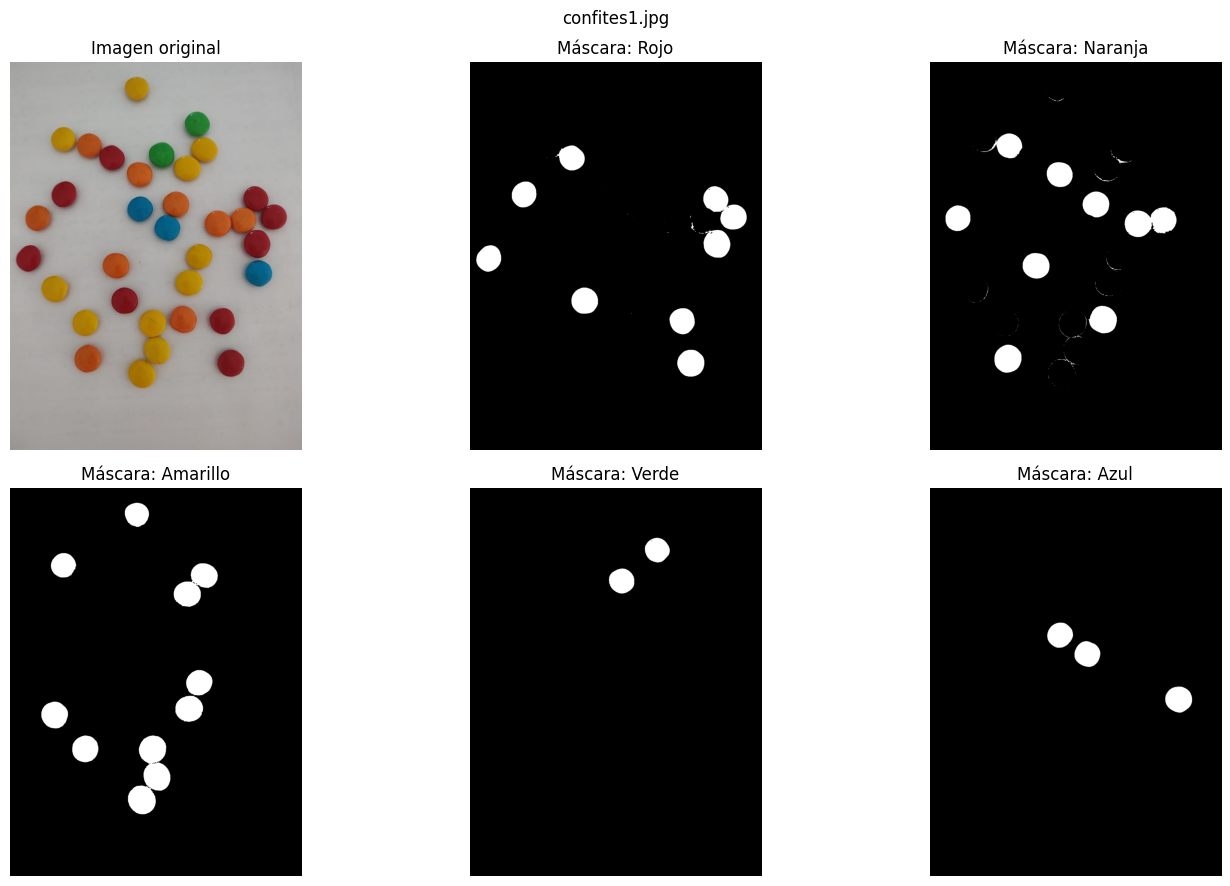

confites2.jpg: imagen (1200, 1600, 3) - máscara (1200, 1600)


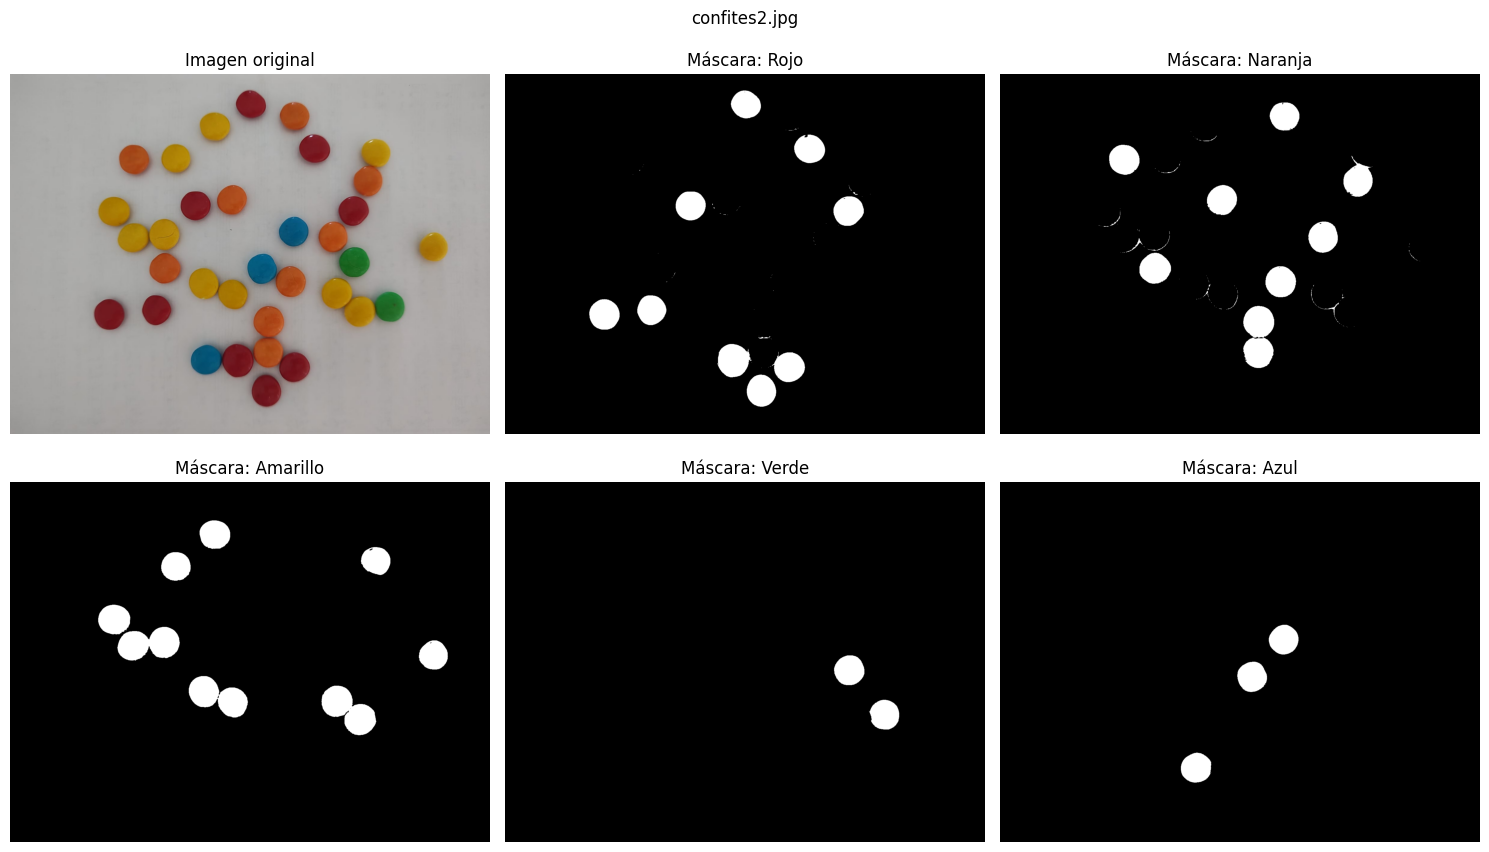

confites3.jpg: imagen (1600, 1200, 3) - máscara (1600, 1200)


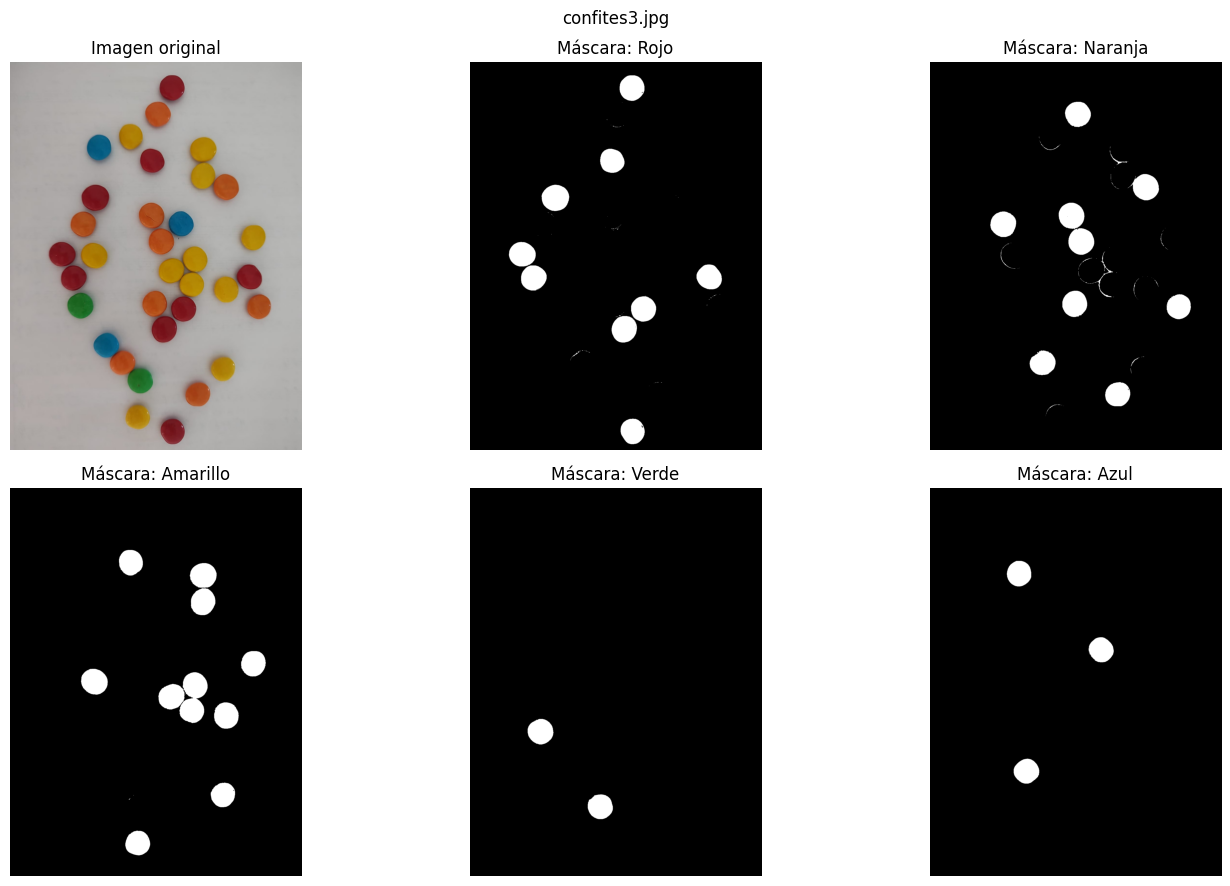

In [8]:
input_path = os.path.join(IMGS_PATH, "inputs")
confites_files = sorted(
    file_name for file_name in os.listdir(input_path)
    if file_name.startswith("confites") and file_name.endswith(".jpg")
)

red_lower_1 = np.array([0, 100, 70])
red_upper_1 = np.array([5, 255, 255])
red_lower_2 = np.array([168, 100, 70])
red_upper_2 = np.array([179, 255, 255])

hsv_ranges = {
    "Naranja": (np.array([6, 100, 70]), np.array([17, 255, 255])),
    "Amarillo": (np.array([18, 100, 70]), np.array([35, 255, 255])),
    "Verde": (np.array([36, 100, 70]), np.array([84, 255, 255])),
    "Azul": (np.array([85, 100, 70]), np.array([115, 255, 255])),
}

for file_name in confites_files:
    img = cv2.imread(os.path.join(input_path, file_name), flags=cv2.IMREAD_COLOR)

    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    red_mask_1 = cv2.inRange(img_hsv, red_lower_1, red_upper_1)
    red_mask_2 = cv2.inRange(img_hsv, red_lower_2, red_upper_2)
    red_mask = cv2.bitwise_or(red_mask_1, red_mask_2)

    masks = {"Rojo": red_mask}
    for color, (lower_bound, upper_bound) in hsv_ranges.items():
        masks[color] = cv2.inRange(img_hsv, lower_bound, upper_bound)

    print(f"{file_name}: imagen {img.shape} - máscara {red_mask.shape}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Imagen original")
    axes[0].axis("off")

    for ax, (color, mask) in zip(axes[1:], masks.items()):
        ax.imshow(mask, cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"Máscara: {color}")
        ax.axis("off")

    fig.suptitle(file_name)
    plt.tight_layout()
    plt.show()

Las máscaras obtenidas permiten separar correctamente, en términos generales, los cinco colores de confites utilizando rangos en el espacio HSV. Se observa que los colores rojo, amarillo, verde y azul quedan bien diferenciados en las tres imágenes. Sin embargo, en la máscara correspondiente al naranja aparecen algunos falsos positivos sobre los bordes de confites amarillos. Esto ocurre porque la umbralización con `cv2.inRange` clasifica cada píxel de manera independiente según sus valores HSV: en las zonas con sombra, algunos píxeles amarillos se oscurecen y adquieren valores suficientemente cercanos al rango definido para el naranja. Por lo tanto, el método funciona bien para una primera segmentación por color, aunque es sensible a variaciones de iluminación dentro de un mismo objeto.

# Análisis de Componentes Conexas

Las componentes conexas se definen como regiones de píxeles adyacentes que tienen un mismo valor de entrada o "etiqueta".
Al trabajar con imágenes binarias, una componente conexa es un conjunto de píxeles adyacentes entre sí que poseen valor 1 (o 255).

La vecidad entre píxeles puede definirse como:
- 4-Connectivity: se consideran vecinos los píxeles que están horizontal o verticalmente adyacentes al píxel central: (-1, 0) (+1, 0), (0, -1), (0, +1).

- 8-Connectivity: igual a 4-Connectivity pero además se consideran vecinos los píxeles que están en diagonal adyacentes al píxel central: (-1, -1) (-1, +1), (+1, -1), (+1, +1).

<img src="https://www.dropbox.com/scl/fi/jqhsealntsqqihxpcx6fv/conncomp.png?rlkey=cq7cpui4tt4l7d0ocycmpjtp9&st=qhfx2asz&dl=1">

Para lograr una segmentación en componentes conexas, es posible interpretar una imagen como un grafo:

<img src="https://www.dropbox.com/scl/fi/h9wyd5q9icg1zgxbemsko/image_graph1.png?rlkey=dya4f541946479i9wjpu98rw4&st=yuam8kvp&dl=1">


<img src="https://www.dropbox.com/scl/fi/zgw22s4c7miglkqed2olt/image_graph2.png?rlkey=fln3ffrlj60e60zmh9wyv94tf&st=ny5t3jdm&dl=1">

Este tipo de representaciones dieron lugar a un área de estudio conocida como Procesamiento de Imágenes basado en Grafos (*Graph-based image processing*).
Los algoritmos que permiten encontrar componentes conexas eficientemente provienen, entonces, del área de teoría de grafos.

Es posible encontrar componentes conexas de un grafo utilizando DFS (*Depth First Search*) apilando los índices de los vecinos visitados ([Connected Components in an Undirected Graph](https://www.geeksforgeeks.org/connected-components-in-an-undirected-graph/)).

Al trabajar con imágenes (grillas bidimensionales) es posible aplicar algoritmos aún más eficientes, como el *Two-Pass Algorithm* ([Implementing a Connected Component Labeling algorithm from scratch](https://medium.com/towards-data-science/implementing-a-connected-component-labeling-algorithm-from-scratch-94e1636554f).

OpenCV provee las funciones [`cv2.connectedComponents` y `cv2.connectedComponentsWithStats`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gaedef8c7340499ca391d459122e51bef5), que se utilizan para encontrar componentes conexas en imágenes.





### Ejemplo de utilización de cv2.connectedComponentsWithStats()

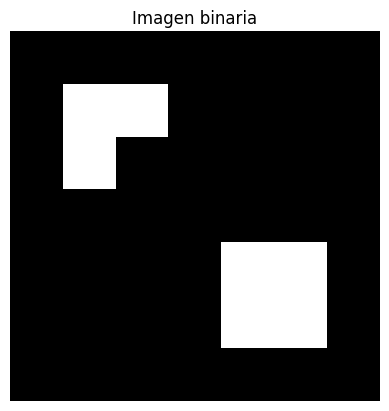

CC0 tiene 42 píxeles.
CC1 tiene 3 píxeles.
CC2 tiene 4 píxeles.


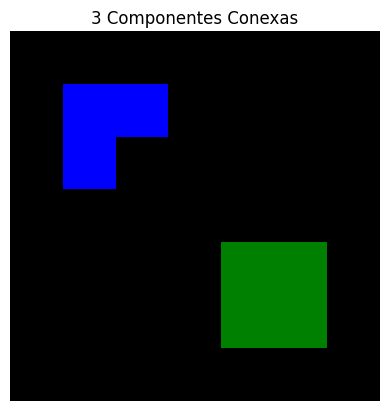

In [4]:

from matplotlib.colors import ListedColormap

# Inicializamos una imagen binaria
binary_img = np.zeros((7, 7)).astype('uint8')
binary_img[1, 1] = 255
binary_img[1, 2] = 255
binary_img[2, 1] = 255

binary_img[4, 4] = 255
binary_img[5, 5] = 255
binary_img[5, 4] = 255
binary_img[4, 5] = 255

plt.figure()
utils.imshow(binary_img)
plt.title("Imagen binaria")
plt.show()


(num_labels, img_labels, values, centroids) = cv2.connectedComponentsWithStats(binary_img)

for i in range(num_labels):
    area = values[i, cv2.CC_STAT_AREA]
    print("CC" + str(i) + " tiene " + str(area) + " píxeles.")

# El fondo también es una componente conexa
cmap = ListedColormap(['black', 'blue', 'green'])

plt.figure()
utils.imshow(img_labels, cmap=cmap)
plt.title(str(num_labels) + " Componentes Conexas")
plt.show()

### Ejercicio 2:

Codificar una función en Python que dada una imagen de entrada con confites, segmente cada confite y cuente la cantidad de confites que hay de cada color. 
Esta función debe utilizar el método de las máscaras binarias obtenidos del ejercicio anterior, mediante el algoritmo de componentes conexas.

Pueden suponer que todas las imágenes son (y serán) tomadas a la misma distancia, es decir, los confites son siempre "aproximadamente" del mismo tamaño. 


Deberán ejecutar y mostrar los resultados de segmentación y cantidad de confites de cada color **para las 3 imágenes de confites provistas en la carpeta  `imgs/inputs/`**.

Ejemplo de salida esperada:

```
    # input: confites1.jpg
    
    ## Total de confites por color:
    
    rojos: 9
    naranjas: 9
    amarillos: 11
    verdes: 2
    azules: 3

    ## Visualización:
```
<img src="https://www.dropbox.com/scl/fi/sojut5c0aob16si7qtsy9/confites1-output.png?rlkey=inzogvvvrnjpylis3w7jgj75z&st=4iyx649r&dl=1" width='50%'>


In [5]:
# TODO: RESOLVER EJERCICIO 2

# Algoritmos de umbralización

## Algoritmo de Otsu

Se conoce como imagen bimodal a aquella que consta de dos picos de intensidad principales. Estos picos o modos representan diferentes objetos, texturas o regiones dentro de la imagen que son significativamente diferentes entre sí en términos de niveles de intensidad.

El método de Otsu, llamado así por su creador Nobuyuki Otsu, permite encontrar un valor de umbralización global óptimo para imágenes bimodales. Este se basa en maximizar la varianza entre clases, una medida conocida utilizada en el análisis estadístico, (Capítulo 10.3; "Digital Image Processing", Gonzalez et al.).

Una animación que describe su accionar:

![OtsuVariance](https://upload.wikimedia.org/wikipedia/commons/3/34/Otsu%27s_Method_Visualization.gif "intra-class variance")

Visto de otro modo, el algoritmo de Otsu busca iterativamente el valor umbral $t$ que minimice la varianza "dentro de las clases", la cual se define como la suma ponderada de las varianzas de las dos clases. Estas dos clases se refieren en general como fondo (*background*) y primer plano (*foreground*).

De forma matemática, se busca el $t$ que minimice la varianza $\sigma_w^2(t)$:

$\underset{t}{\mathrm{argmin}} \: \sigma_w^2(t) = \underset{t}{\mathrm{argmin}} \: q_{bg}(t)\sigma_{bg}^2(t)+q_{fg}(t)\sigma_{fg}^2(t)$

donde:

$q_{bg}(t) = \sum_{i=1}^{t} p(i) \quad , \quad q_{fg}(t) = \sum_{i=t+1}^{I} p(i)$

$\mu_{bg}(t) = \sum_{i=1}^{t} \frac{ip(i)}{q_{bg}(t)} \quad , \quad \mu_{fg}(t) = \sum_{i=t+1}^{I} \frac{ip(i)}{q_{fg}(t)}$

$\sigma_{bg}^2(t) = \sum_{i=1}^{t} [i-\mu_{bg}(t)]^2 \frac{p(i)}{q_{bg}(t)} \quad , \quad \sigma_{fg}^2(t) = \sum_{i=t+1}^{I} [i-\mu_{fg}(t)]^2 \frac{p(i)}{q_{fg}(t)}$

donde $p(i)$ refieren al valor de frecuencia para la intensidad $i$.

## Algoritmos de umbralización adaptativa

En el caso del algoritmo de Otsu se utiliza un valor de umbral global, pero esto puede no ser suficiente en algunos casos, por ejemplo cuando una imagen presenta condiciones de iluminación muy variante.

Un algoritmo de binarización adaptativa determina un valor de umbral local para cada píxel en base al análisis de una pequeña región a su alrededor.

Un ejemplo de política adaptativa de umbralización para un determinado píxel es considerar como umbral la media de intensidad del área vecina al mismo. Si el píxel central es mayor que la media de sus vecinos entonces se lo binariza a 255 (o 1) y 0 en otro caso.

### Ejemplos de umbralización de Otsu y adaptativas

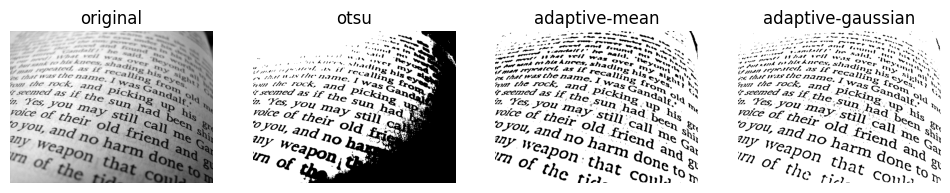

In [6]:
book_img = cv2.imread(IMGS_PATH + "resources/book.jpg", cv2.IMREAD_GRAYSCALE)

# Umbralización utilizando el algoritmo de Otsu
th, otsu_thresh = cv2.threshold(book_img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Umbralización adaptativa utilizando utilizando la media del kernel
mean_thresh = cv2.adaptiveThreshold(
    book_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, blockSize=19, C=16
)

# Umbralización adaptativa utilizando un kernel gaussiano
gaussian_thresh = cv2.adaptiveThreshold(
    book_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C ,
    cv2.THRESH_BINARY, blockSize=19, C=16
)

utils.show_images([book_img, otsu_thresh, mean_thresh, gaussian_thresh], ["original", "otsu", "adaptive-mean", "adaptive-gaussian"])

## Análisis morfológico de imágenes

La Morfología Matemática es una técnica de procesamiento y análisis de imágenes que tiene como objetivo procesar objetos en las imágenes de manera de extraer características de su "forma" (Capítulo 9, "Digital Image Processing", Gonzalez et al.). Tuvo gran repercusión y dió soluciones a muchos problemas en áreas como las del reconocimiento de texto y segmentación de imágenes médicas.

La morfología matemática se basa en teoría de conjuntos y define una serie de operaciones que permiten aplicar transformaciones a imágenes binarias. Estas transformaciones se basan en evaluar una región vecina alrededor de cada píxel, de manera similar al kernel de una convolución.

Al kernel utilizado en análisis morfológico se lo conoce como elemento estructurante (*structuring element*), y es binario:

<img src="https://www.dropbox.com/scl/fi/6yw34v89uirarkf8skjsi/structuring_element.png?rlkey=fczhihhms8sf0194pdn8gpuzc&st=aortt9m7&dl=1" />



### Operador de Erosión:
Un píxel en la imagen binarizada (0 o 255) será considerado 255 solo si todos los píxeles bajo el elemento estructurante son 1, de otra manera el píxel es erosionado (puesto en 0). Esta transformación erosiona las componentes conexas presentes en la imágen binaria, reduciendo su "grosor".

Ejemplo de erosión utilizando un elemento estructurante cuadrado de 5x5:

<img src="https://www.dropbox.com/scl/fi/yaold6pc4vzlgr4xdp4ms/erode.png?rlkey=v3u0px8okpx06q4n42djesm9d&st=d90p3qo9&dl=1">

### Operador de Dilatación:
Esta operación es la opuesta a la erosión, un píxel en la imagen binarizada será evaluado en 255 si al menos un píxel del elemento estructurante es 1.

Un píxel en la imagen binarizada (0 o 255) será considerado 255 solo si todos los píxeles bajo el elemento estructurante son 1, de otra manera el píxel es erosionado (puesto en 0). Esta transformación produce una dilatación de las componentes conexas, ensanchándolas.

Ejemplo de dilatación utilizando un elemento estructurante cuadrado de 5x5:

<img src="https://www.dropbox.com/scl/fi/j4i4rmh2ym0zj7dmpw9w8/dilation.png?rlkey=u1cs5l56wlh0ndcdbqqntal1n&st=wyozhbl0&dl=1">

### La Transformada de Distancia:
La transformada de distancia reemplaza cada píxel de una imagen binaria con la distancia al píxel del *background* (valores en 0) más cercano. Si el píxel en sí ya forma parte del fondo, entonces esto es 0. El resultado es una imagen llamada mapa de distancias.

Ejemplo de un mapa de distancias aplicado a una región:

<img src="https://www.dropbox.com/scl/fi/bt5cqhlxon76d0kzg69kx/distance_transform.png?rlkey=qnkg1zjyn3uoqhxmtadds6bpf&st=t7jggu3v&dl=1">
    

A partir de estos operadores y transformaciones básicas, el análisis morfológico define muchas otras operaciones más complejas, las cuales son ampliamente utilizadas en imágenes médicas, un recurso interesante es el ebook [Introduction to Bioimage Analysis](https://bioimagebook.github.io/index.html) de Pete Bankhead.

La librería de OpenCV tiene además su propia implementación de operaciones morfológicas: [Image Filters](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html) y [
Morphological Transformations
](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html).

## Supresión de No-Máximos (NMS)

Muchas veces al trabajar con imágenes tenemos un problema recurrente: 
Tenemos un detector, que nos provee soluciones candidatas del mismo objeto varias veces por estar superpuestas. 

Este problema típicamente se puede resolver aplicando el algoritmo de non-maxima supression.

El pseudocódigo en su forma general es:

```python

    algoritmo de nms(C: conjunto de candidatos):
    
        # inicializa el conjunto de resultados vacío
        M := {}
        
        mientras hay candidatos en C: 
            
            m := max(C) 
            
            N := conjunto de vecinos de m en C, según criterio de linkeo
    
            C := C - N
              
            M := M union { m }
            
        devolver M

```

Hint: Para el caso particular en que tenemos blobs superpuestos, podemos usar este método en combinación con la transformada de distancia y un radio estadístico como criterio de linkeo. 


## Ejercicio 3

Considerando todos los conceptos antes mencionados hasta ahora en este trabajo práctico, se pide contar la cantidad de células rojas en la imagen `imgs/inputs/blood_cells.jpg` tomada por microscopio:

<img src="https://www.dropbox.com/scl/fi/mb2dfei5j18mwe0sbzr6k/blood_cells.jpg?rlkey=zrrjniuzt7k9tor3nlphx16u9&st=gn0v6kcd&dl=1" width='40%'>

Las células rojas corresponden a los elementos de color 'rojo'/'rosado', pero deben notar que existen otros elementos de color 'azulado'/'púrpura'.
Estas otras células corresponden a células blancas presentes en la sangre. Notar que existen además otras pequeñas partículas en la imagen.

Deben entonces desarrollar en Python que dada una imagen de entrada con estas características,
 cuente la cantidad de células rojas descartando cualquier otra células o partículas presentes en la imagen.
de manera automática.

A continuación un ejemplo del resultado esperado por el método:

<img src="https://www.dropbox.com/scl/fi/r6xf7hzcvs3ra4vbhj95j/celulas-output.png?rlkey=m7sv1i7e2hl6odq2oq7xre3a3&st=qhn2alto&dl=1" width='50%'>

Importante:
- **La solución NO DEBERÍA contar varias veces la misma célula**
- **La solución NO DEBERÍA contar una sola vez varias células pegadas**
- Deberán graficar el centroide de cada célula detectada.

Notas:
- Un conteo entre 232 y 236 es aceptable.
- Pueden suponer que las imágenes serán tomadas siempre a la misma distancia y que los elementos en la imagen son aproximadamente del mismo tamaño siempre.
- Pueden utilizar cualquier función de análisis de imágenes, detección de componentes conexas y contornos en openCV.
- Pueden utilizar operaciones morfológicas, transformación de distancia y supresión de No-Máximos para intentar dividir células rojas "pegadas"
- **Si utilizan material o métodos que no se explicaron en clase, deberán proveer la referencia y explicar cómo funciona con su correspondiente base teórica**
  

In [7]:
# TODO: RESOLVER EJERCICIO 3